# Exploratory Data Analysis
## Ryan Waterman

### Data Load and Review

In [475]:
import pandas as pd

In [476]:
data = pd.read_csv('./customer_data/customer_data.csv')

In [477]:
data.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [478]:
print(len(data.columns), len(data))

21 10127


In [479]:
data.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [480]:
quantitative = list(data.describe().columns.drop('CLIENTNUM'))
quantitative

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

First, let's check for duplicate client numbers, as this is the primary identifier for the dataset.

In [481]:
if len(data) != len(data['CLIENTNUM'].unique()):
    print(f'There are {len(data) - len(data['CLIENTNUM'].unique())} duplicate client numbers')
else:
    print('All client numbers are unique.')

All client numbers are unique.


So, all clients are unique clients. Let's explore the different categorical columns.

In [482]:
categorical = list(set(data.columns.drop('CLIENTNUM')) - set(quantitative))

for cat in categorical:
    print(f'{cat} Categories: {data[cat].unique()}')

Attrition_Flag Categories: ['Existing Customer' 'Attrited Customer']
Income_Category Categories: ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
Gender Categories: ['M' 'F']
Education_Level Categories: ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
Marital_Status Categories: ['Married' 'Single' 'Unknown' 'Divorced']
Card_Category Categories: ['Blue' 'Gold' 'Silver' 'Platinum']


In [483]:
categorical

['Attrition_Flag',
 'Income_Category',
 'Gender',
 'Education_Level',
 'Marital_Status',
 'Card_Category']

In [484]:
len(categorical)

6

### Variable Analysis

In [485]:
import matplotlib.pyplot as plt

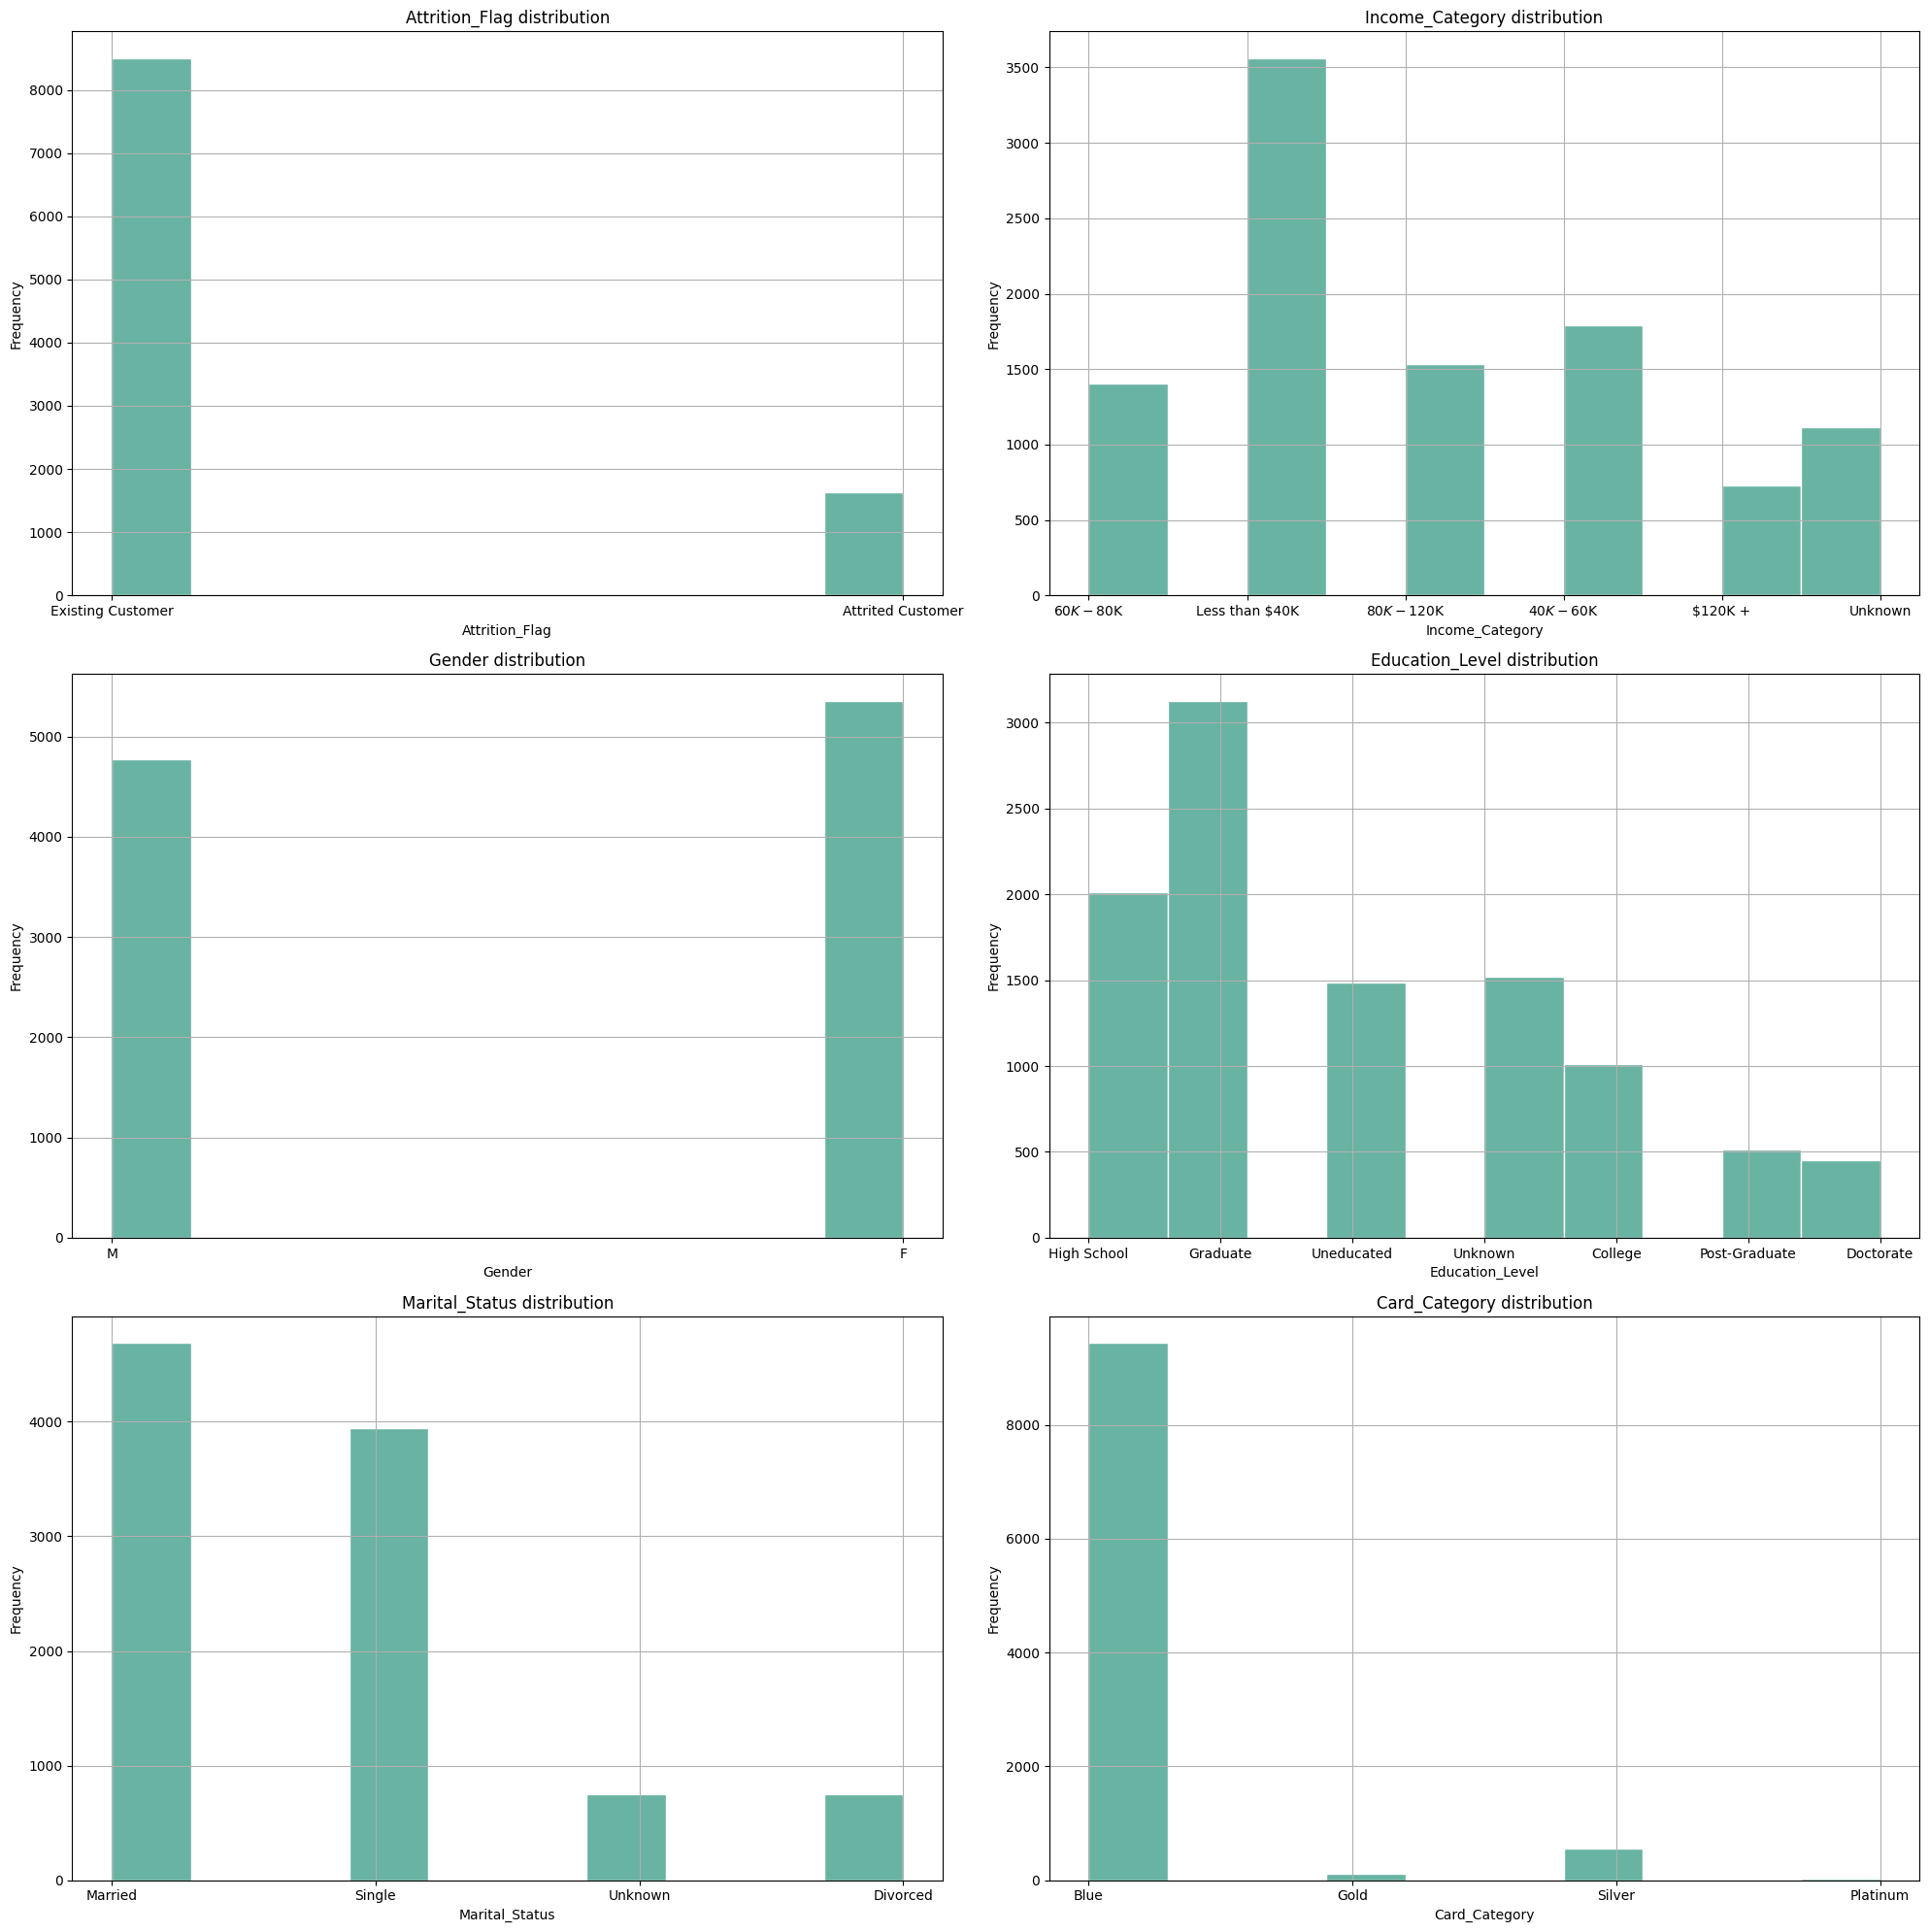

In [486]:
fig, axes = plt.subplots(3,2,figsize = (20, 20))
axes = axes.flatten()

for i, cat in enumerate(categorical):
    # Add the histogram
    data[cat].hist(ax=axes[i], # Define on which ax we're working on
                    edgecolor='white', # Color of the border
                    color='#69b3a2' # Color of the bins
                   )
    
    # Add title and axis label
    axes[i].set_title(f'{cat} distribution') 
    axes[i].set_xlabel(cat) 
    axes[i].set_ylabel('Frequency') 

plt.tight_layout()

# Show the plot
plt.show()

In [487]:
correlation_table = data[quantitative].corr()
correlation_table

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
Customer_Age,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114
Dependent_count,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135
Months_on_book,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541
Total_Relationship_Count,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663
Months_Inactive_12_mon,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503
Contacts_Count_12_mon,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471
Credit_Limit,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965
Total_Revolving_Bal,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022
Avg_Open_To_Buy,0.001151,0.068291,0.006732,-0.072601,-0.016605,0.025646,0.995981,-0.047167,1.000000,0.007595,0.165923,0.070885,-0.010076,-0.538808
Total_Amt_Chng_Q4_Q1,-0.062042,-0.035439,-0.048959,0.050119,-0.032247,-0.024445,0.012813,0.058174,0.007595,1.000000,0.039678,0.005469,0.384189,0.035235


In [488]:
positive_correlations = {col:val for col, val in correlation_table[correlation_table != 1].max().items() if val > 0.75}

In [489]:
negative_correlations = {col:val for col, val in correlation_table[correlation_table != 1].min().items() if val < -0.35}

In [497]:
negative_correlations

{'Credit_Limit': -0.4829650714174503,
 'Avg_Open_To_Buy': -0.5388077476174624,
 'Avg_Utilization_Ratio': -0.5388077476174624}

In [498]:
unique_positive_correlations = {}
unique_negative_correlations = {}

for col, val in positive_correlations.items():
    if col not in unique_positive_correlations.keys() and col not in unique_positive_correlations.values():
        unique_positive_correlations[col] = correlation_table[correlation_table[col] == val].index[0]
    
for col, val in negative_correlations.items():
    if col not in unique_negative_correlations.keys() and col not in unique_negative_correlations.values():
        unique_negative_correlations[col] = correlation_table[correlation_table[col] == val].index[0]

print(unique_positive_correlations)
print(unique_negative_correlations)

{'Customer_Age': 'Months_on_book', 'Credit_Limit': 'Avg_Open_To_Buy', 'Total_Trans_Amt': 'Total_Trans_Ct'}
{'Credit_Limit': 'Avg_Utilization_Ratio', 'Avg_Open_To_Buy': 'Avg_Utilization_Ratio'}


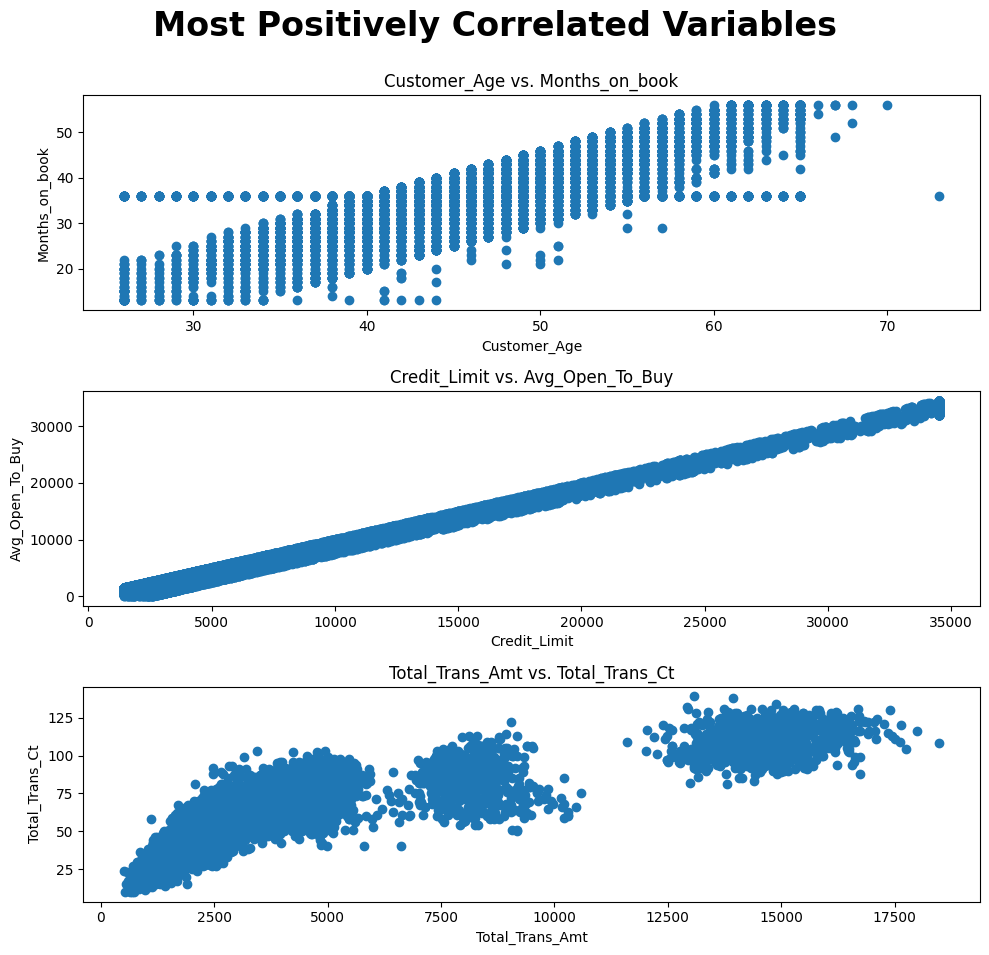

In [502]:
fig, axes = plt.subplots(3,1,figsize = (10, 10))
axes = axes.flatten()

fig.suptitle('Most Positively Correlated Variables', fontsize = 24, fontweight = 'bold')

for i, (key, val) in enumerate(unique_positive_correlations.items()):
    var1 = key
    var2 = val

    # Add the histogram
    axes[i].scatter(x=data[var1], y=data[var2])
    
    # Add title and axis label
    axes[i].set_title(f'{var1} vs. {var2}') 
    axes[i].set_xlabel(var1) 
    axes[i].set_ylabel(var2) 
    
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Show the plot
plt.show()

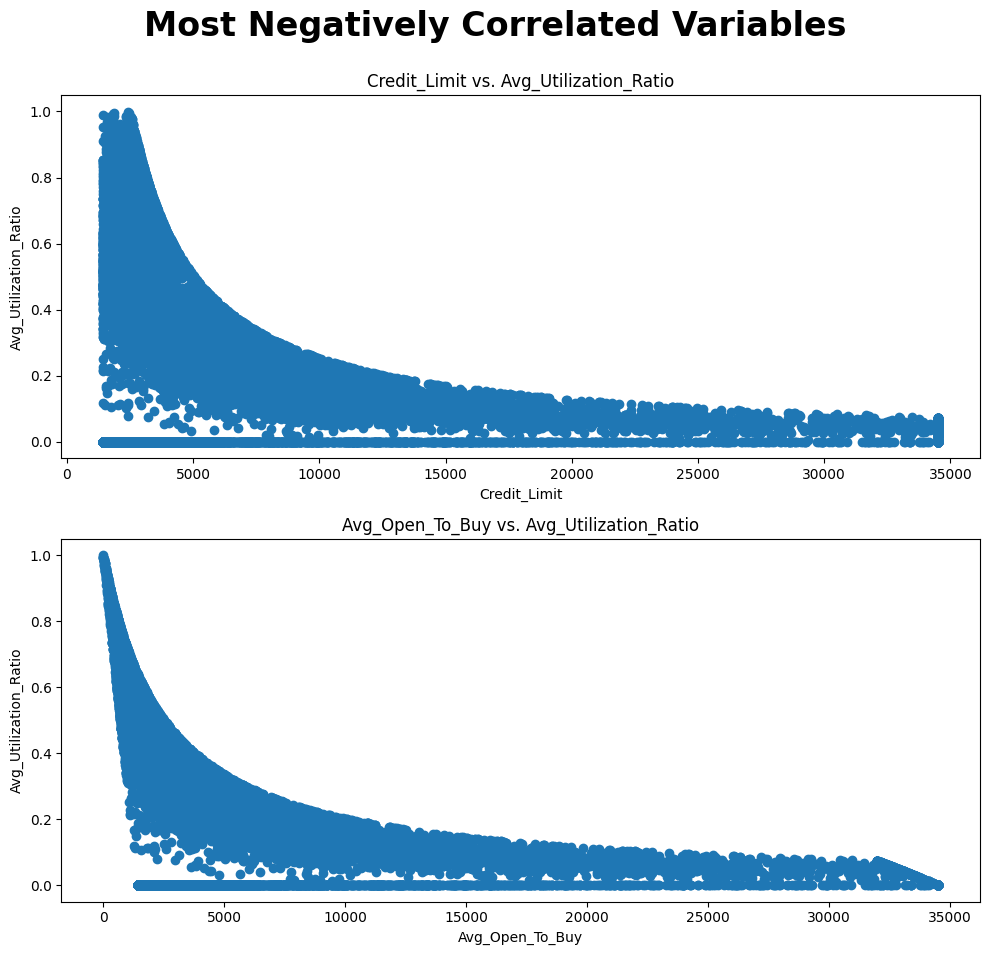

In [503]:
fig, axes = plt.subplots(2,1,figsize = (10, 10))
axes = axes.flatten()

fig.suptitle('Most Negatively Correlated Variables', fontsize = 24, fontweight = 'bold')

for i, (key, val) in enumerate(unique_negative_correlations.items()):
    var1 = key
    var2 = val

    # Add the histogram
    axes[i].scatter(x=data[var1], y=data[var2])
    
    # Add title and axis label
    axes[i].set_title(f'{var1} vs. {var2}') 
    axes[i].set_xlabel(var1) 
    axes[i].set_ylabel(var2) 
    
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Show the plot
plt.show()

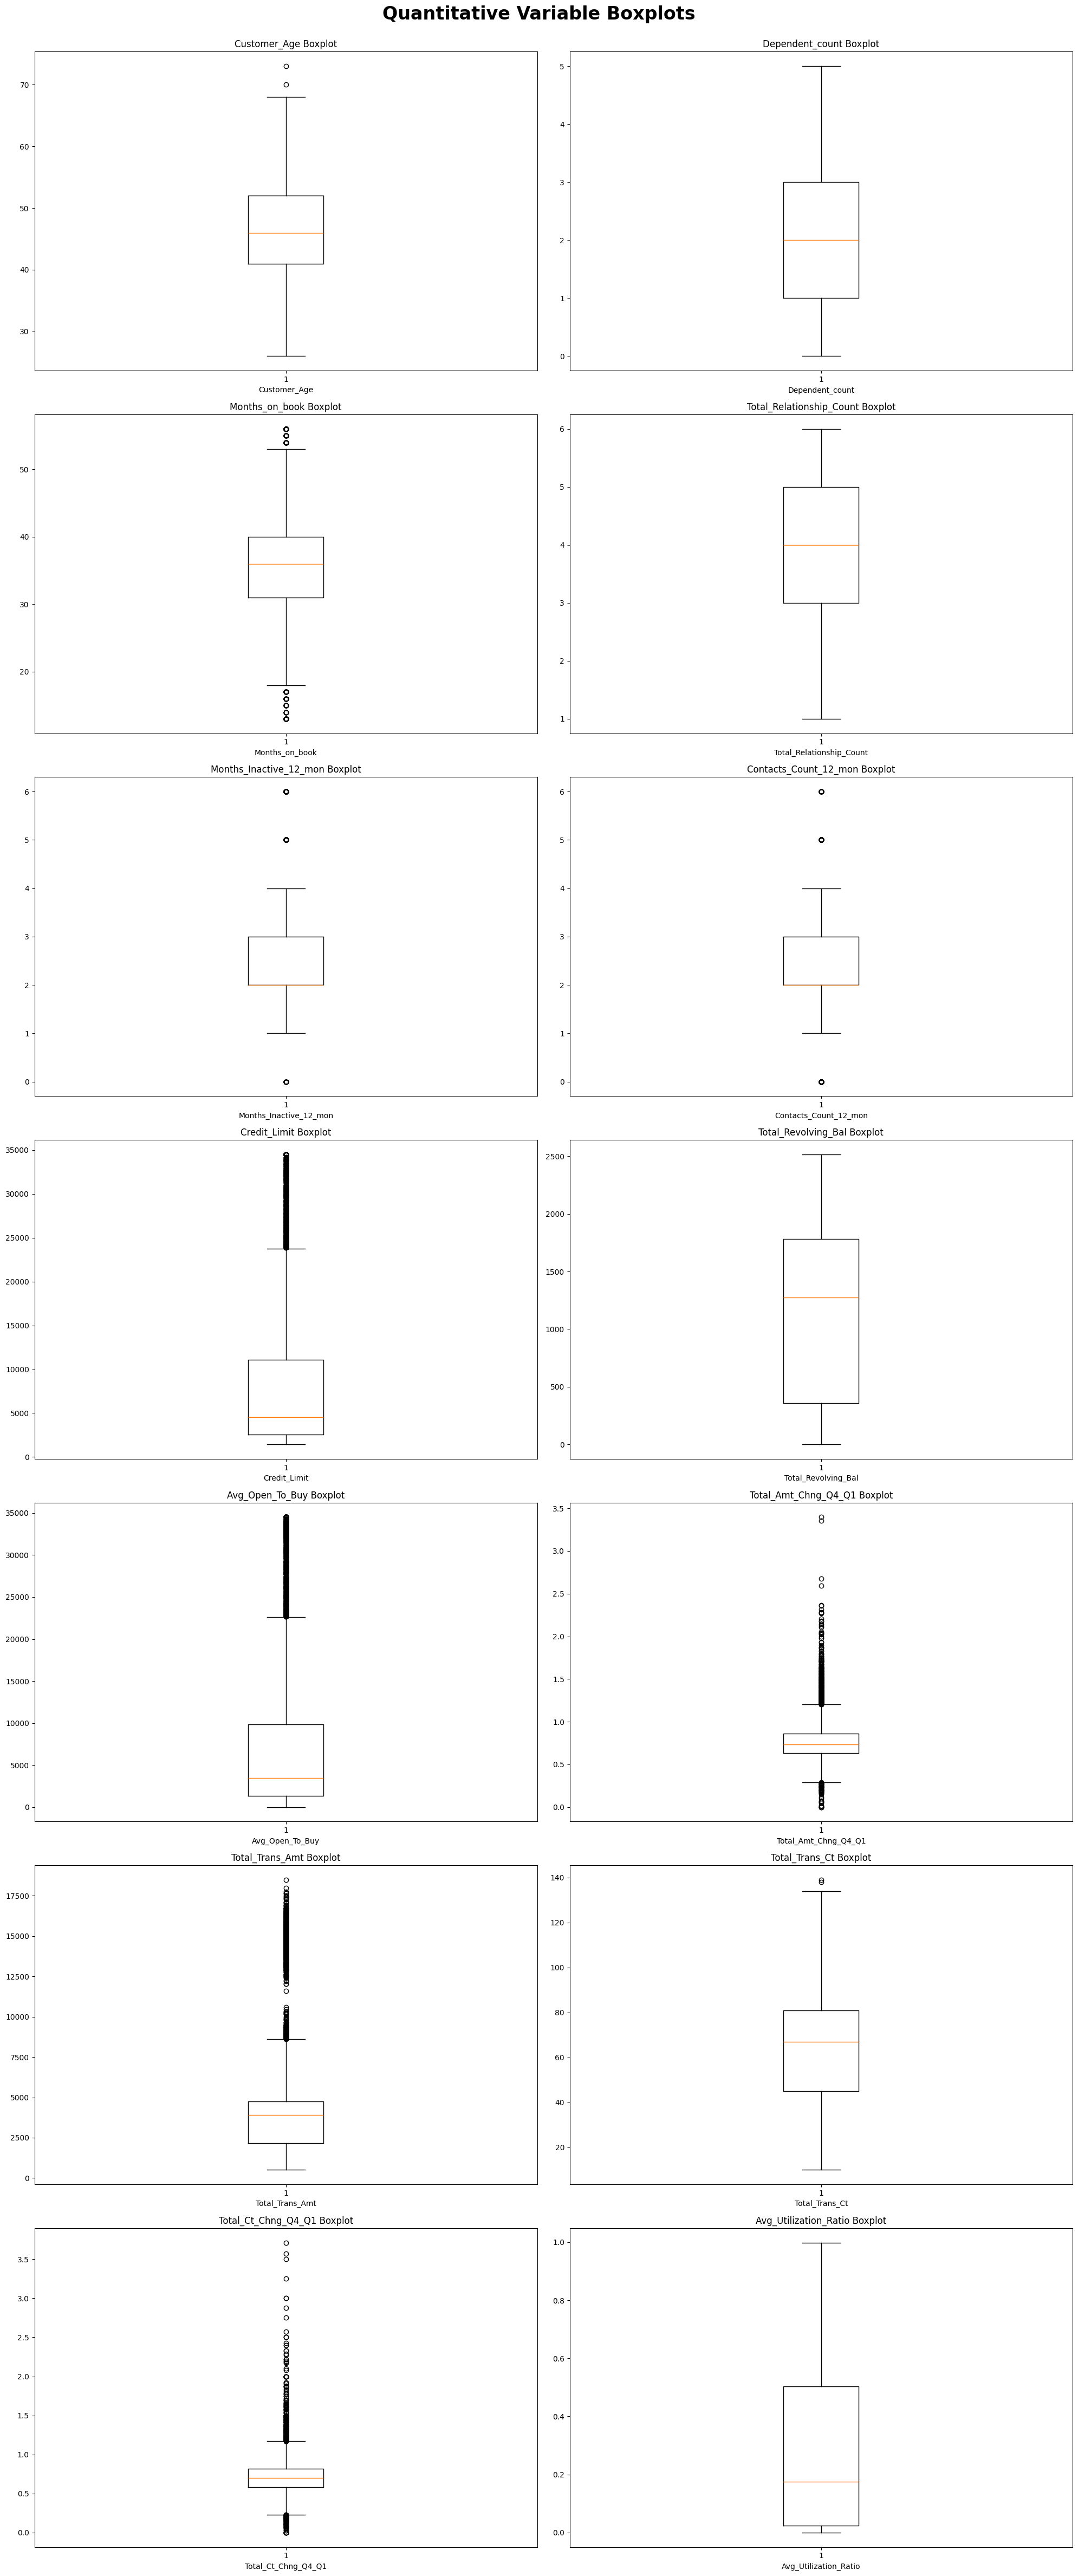

In [493]:
fig, axes = plt.subplots(7,2,figsize = (20, 50))
axes = axes.flatten()

fig.suptitle('Quantitative Variable Boxplots', fontsize = 24, fontweight = 'bold')

for i, col in enumerate(quantitative):

    # Add the histogram
    axes[i].boxplot(data[col])
    
    # Add title and axis label
    axes[i].set_title(f'{col} Boxplot') 
    axes[i].set_xlabel(col) 
    
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Show the plot
plt.show()

In [494]:
outliers = {}

for col in quantitative:
    # Calculate Q1, Q3, and IQR
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers[col] = [len(data[(data[col] < lower_bound) | (data[col] > upper_bound)][col].values)]


In [495]:
outliers = pd.DataFrame(outliers)

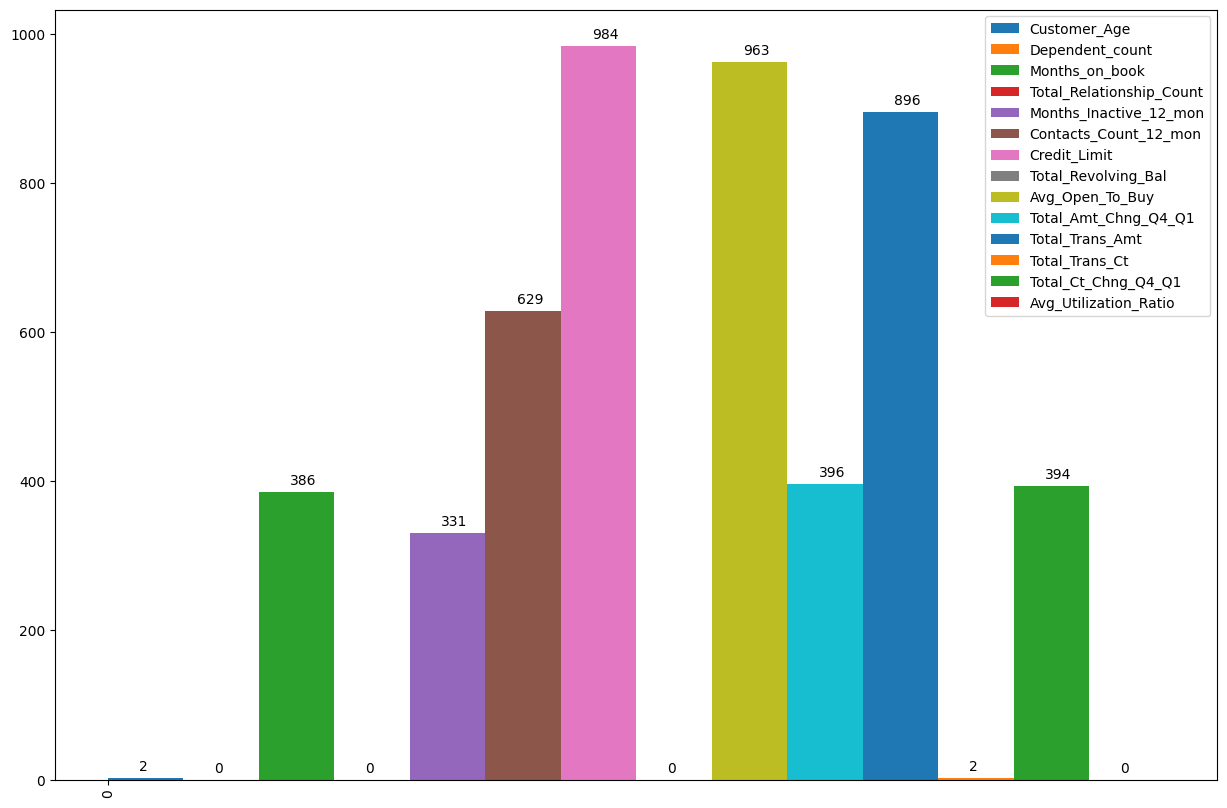

In [496]:
bar_plot = outliers.plot.bar(figsize=(15, 10), width=5, align = 'edge')
x_offset = -0.03
y_offset = 10
for p in bar_plot.patches:
    b = p.get_bbox()
    val = f'{int(b.y1 + b.y0)}'     
    bar_plot.annotate(val, ((b.x0 + b.x1)/2 + x_offset, b.y1 + y_offset))